<a href="https://colab.research.google.com/github/Gitstrong3333/MachineLearning_Python-/blob/main/Copy_of_Stock_FullCode_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 122.9 MB/s eta 0:00:00


In [ ]:
# Importing library for data manipulation
import pandas as pd

# Importing library for numerical operations
import numpy as np

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to use regular expressions for manipulating text data
import re

# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
# nltk.download('punkt')    # loading the punkt module used in tokenization
# nltk.download('omw-1.4')    # dependency for tokenization
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# Import the gensim library
from gensim.models import KeyedVectors

# to perform stemming
from nltk.stem.porter import PorterStemmer

# To import Word2Vec
from gensim.models import Word2Vec

# To split data into train and test sets
from sklearn.model_selection import train_test_split, GridSearchCV

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

#Import the decision tree classifier from sklearn
from sklearn.tree import DecisionTreeClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# To used time-related functions
import time

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# Import the necessary function from scikit-learn
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
!pip install triton

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 4.3 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/stock_news.csv'
data = pd.read_csv(file_path)


In [ ]:
# checking the first five rows of the data
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [ ]:
# checking the shape of the data
data.shape

(349, 8)

In [ ]:
# checking for missing values
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

**Exploratory Data Analysis**

**Univariate Analysis**

 Distribution of individual variables
Compute and check the distribution of the length of news content

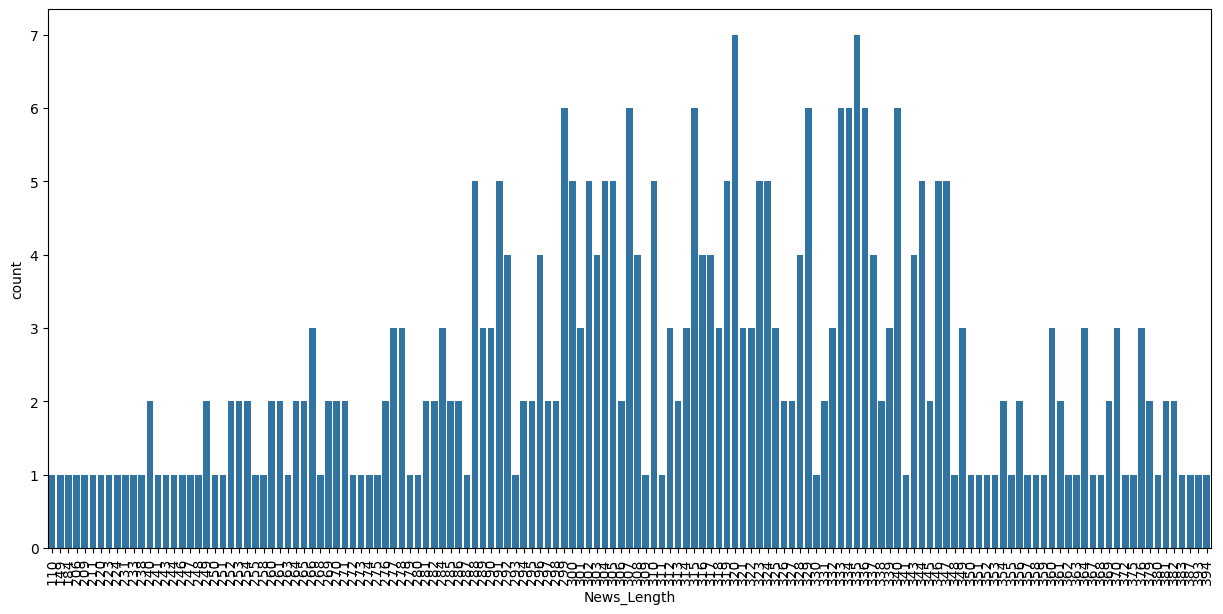

In [ ]:
# Compute the length of each news article
data['News_Length'] = data['News'].apply(len)

# Check the distribution of the length of News
plt.subplots(figsize = (15,7))
sns.countplot(data=data, x='News_Length', )
plt.xticks(rotation = 90);

Observation

The news length has a slightly normal distribution.

There are 7 different news contents with 320 letters and another 7 different new content with 335 letters.

<Axes: xlabel='Label', ylabel='count'>

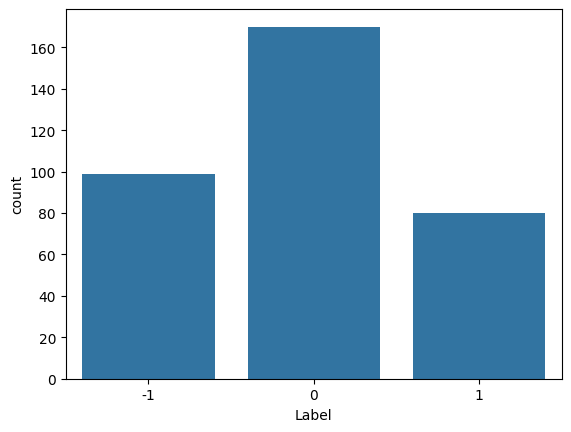

In [ ]:
#Compute the distribution of 'Label' or sentiment
sns.countplot(data=data, x='Label',)

**Observation**

There more neutral sentiments out of all, followed by negative sentiments, and lastly postive sentiments.

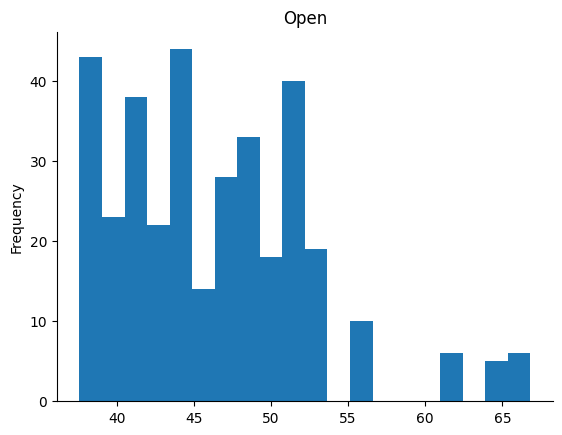

In [ ]:
# Compute the distribution of 'Open' variable
from matplotlib import pyplot as plt
data['Open'].plot(kind='hist', bins=20, title='Open')
plt.gca().spines[['top', 'right',]].set_visible(False)

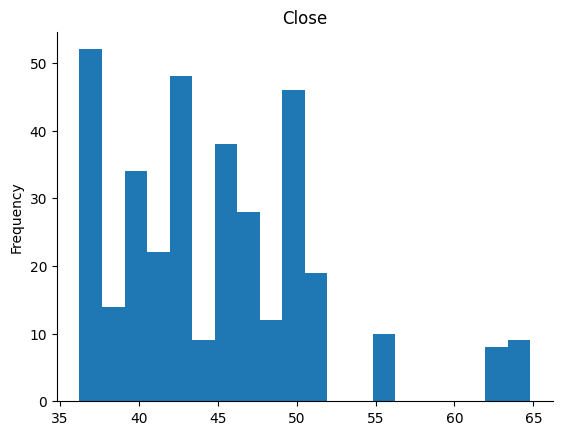

In [ ]:
# Compute the distribution of 'Open' variable
from matplotlib import pyplot as plt
data['Close'].plot(kind='hist', bins=20, title='Close')
plt.gca().spines[['top', 'right',]].set_visible(False)

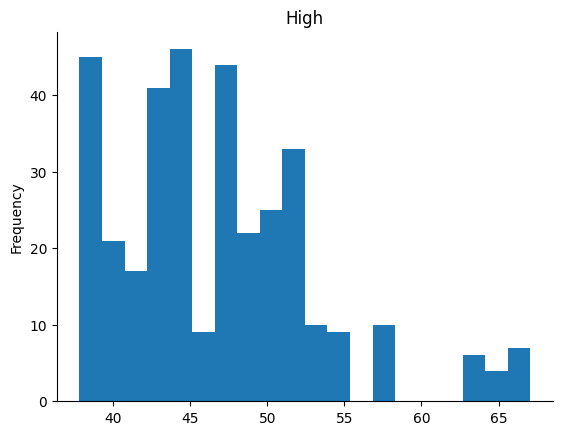

In [ ]:
# Compute the distribution of 'High' variable
from matplotlib import pyplot as plt
data['High'].plot(kind='hist', bins=20, title='High')
plt.gca().spines[['top', 'right',]].set_visible(False)

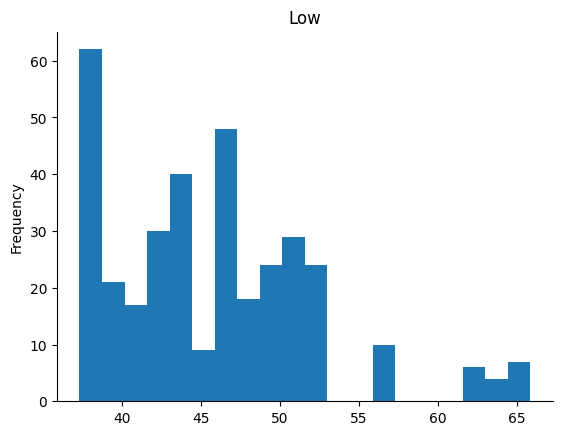

In [ ]:
# Compute the distribution of 'Low' variable
from matplotlib import pyplot as plt
data['Low'].plot(kind='hist', bins=20, title='Low')
plt.gca().spines[['top', 'right',]].set_visible(False)

Observation

The histogram plots of 'high', 'low', 'open', and 'close' variables are right skewed.

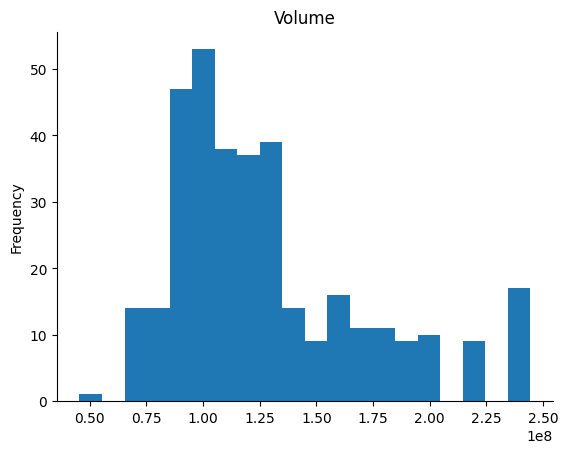

In [ ]:
# Compute the distribution of 'Volume' variable
from matplotlib import pyplot as plt
data['Volume'].plot(kind='hist', bins=20, title='Volume')
plt.gca().spines[['top', 'right',]].set_visible(False)

**Observation**

The histogram plot of 'volume' variable is right skewed.

**Bivariate Analysis**

**Correlation**

Sentiment Polarity vs Price **bold text**

Date vs Price

Note: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

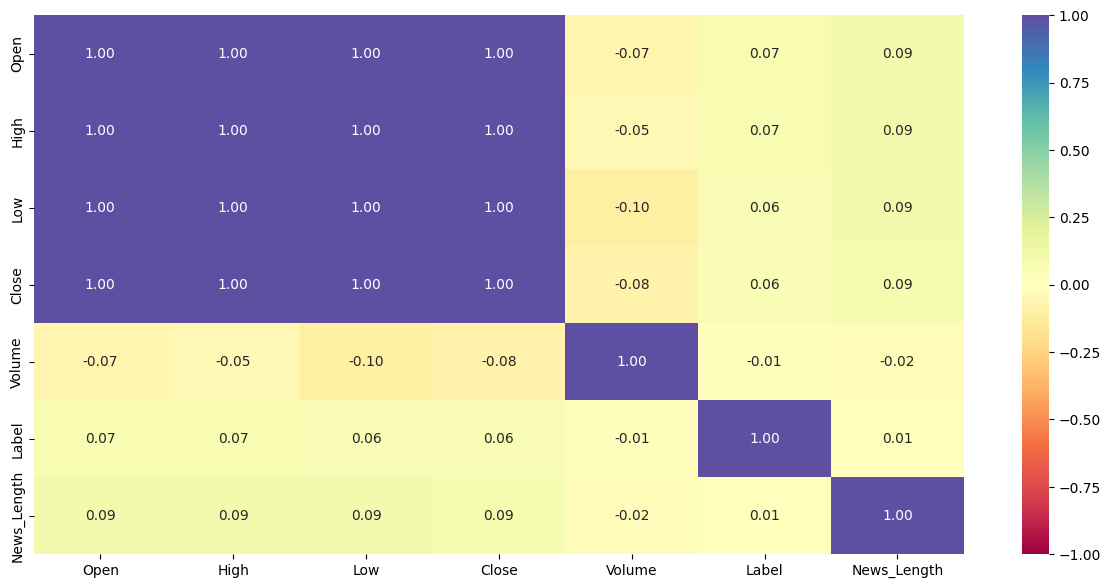

In [ ]:
# Plot the Heat Map of all the numerical attributes
numerical_data = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(15, 7))
sns.heatmap(numerical_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Observations

The 'Open', 'High', 'Low', & ' Close' attribute have 100% collinearity amongst one another.

'Volume' has a negative correlation to all other variables.

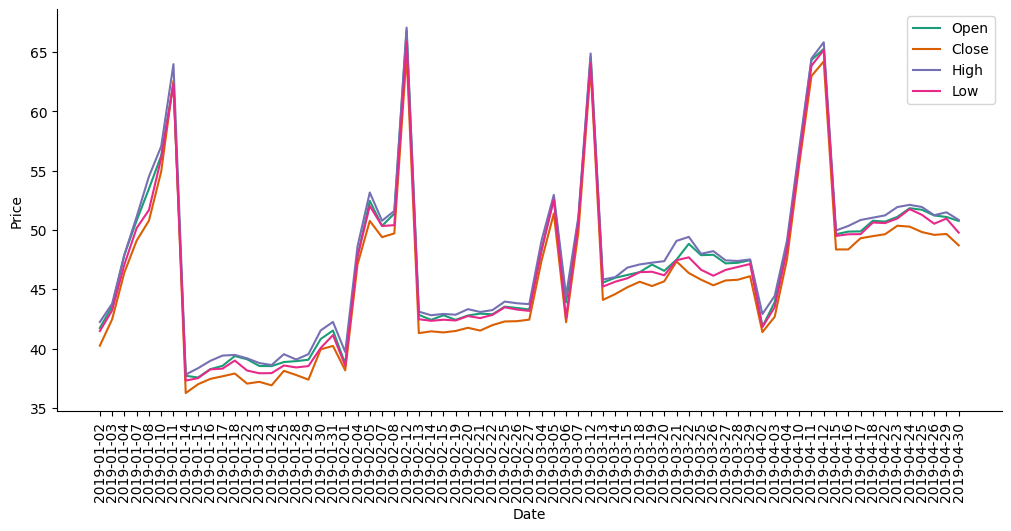

In [ ]:
# Plot Time vs Price
# Function to plot multiple series
def plot_series(series, y_columns):
    palette = sns.color_palette('Dark2', len(y_columns))
    xs = series['Date']

    # Plot each specified y_column with corresponding label and color
    for i, y_col in enumerate(y_columns):
        plt.plot(xs, series[y_col], label=y_col, color=palette[i])

# Create and sort the dataframe
fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('Date')

# Plot 'Open', 'Close', 'High', and 'Low' on the y-axis
plot_series(df_sorted, ['Open', 'Close', 'High', 'Low'])

# Format the plot
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.legend()

# Display plot
plt.show()

Observation
**bold text**
The Close and Open prices appear to follow a similar trend, indicating that the market doesn’t experience drastic changes overnight.
The High and Low prices show the daily volatility, with the High prices generally being higher than the Open and Close prices, and the Low prices being lower.

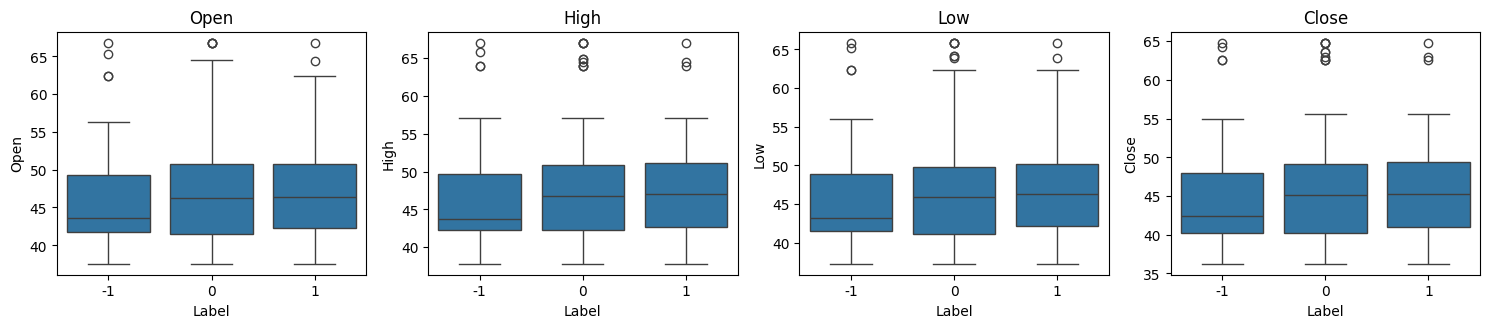

In [ ]:
# outlier detection using boxplot
price_columns = data.select_dtypes(include=['float64']).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(price_columns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x='Label', y=data[variable], data=data)
    #plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observation**

It evident that the median prices are typically lower with negative sentiments (-1 Label) and the median prices are generally higher with positive sentiments (1 Label).

**Data Preprocessing**



**Removing Special Characters**

In [ ]:
# defining a function to remove special characters
def remove_special_characters(text):
    # Defining the regex pattern to match non-alphanumeric characters
    pattern = "[^A-Za-z0-9']+"

    # Finding the specified pattern and replacing non-alphanumeric characters with a blank string
    new_text = ''.join(re.sub(pattern, ' ', text))


    # Remove apostrophes as well, uncomment the following line:
    new_text = new_text.replace("'", "")

    # Return the processed text
    return new_text

In [ ]:
# Applying the function to remove special characters
data['cleaned_text'] = data['News'].apply(remove_special_characters)

In [ ]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['News','cleaned_text']]

,News,cleaned_text
0,The tech sector experienced a significant dec...,The tech sector experienced a significant dec...
1,Apple lowered its fiscal Q1 revenue guidance ...,Apple lowered its fiscal Q1 revenue guidance ...
2,Apple cut its fiscal first quarter revenue fo...,Apple cut its fiscal first quarter revenue fo...
3,This news article reports that yields on long...,This news article reports that yields on long...


**Lowercasing**

In [ ]:
# changing the case of the text data to lower case
data['cleaned_text'] = data['cleaned_text'].str.lower()

In [ ]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['News','cleaned_text']]

,News,cleaned_text
0,The tech sector experienced a significant dec...,the tech sector experienced a significant dec...
1,Apple lowered its fiscal Q1 revenue guidance ...,apple lowered its fiscal q1 revenue guidance ...
2,Apple cut its fiscal first quarter revenue fo...,apple cut its fiscal first quarter revenue fo...
3,This news article reports that yields on long...,this news article reports that yields on long...


**Removing Extra Whitespace**

In [ ]:
# removing extra whitespaces from the text
data['cleaned_text'] = data['cleaned_text'].str.strip()

In [ ]:
# checking a couple of instances of cleaned data
data.loc[0:6, ['News','cleaned_text']]

,News,cleaned_text
0,The tech sector experienced a significant dec...,the tech sector experienced a significant decl...
1,Apple lowered its fiscal Q1 revenue guidance ...,apple lowered its fiscal q1 revenue guidance t...
2,Apple cut its fiscal first quarter revenue fo...,apple cut its fiscal first quarter revenue for...
3,This news article reports that yields on long...,this news article reports that yields on long ...
4,Apple's revenue warning led to a decline in U...,apples revenue warning led to a decline in usd...
5,Apple CEO Tim Cook discussed the company's Q1 ...,apple ceo tim cook discussed the companys q1 w...
6,Roku Inc has announced plans to offer premium...,roku inc has announced plans to offer premium ...


**Remove Stopword**


Remove stop wors and words that appear frequently throughout the document in the corpus.

In [ ]:
# defining a function to remove stop words using the NLTK library
def remove_stopwords(text):
    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    new_text = ' '.join([word for word in words if word not in stopwords.words('english')])

    return new_text

In [ ]:
# Applying the function to remove stop words using the NLTK library
data['cleaned_text_without_stopwords'] = data['cleaned_text'].apply(remove_stopwords)

In [ ]:
# checking a couple of instances of cleaned data
data.loc[0:3,['cleaned_text','cleaned_text_without_stopwords']]

,cleaned_text,cleaned_text_without_stopwords
0,the tech sector experienced a significant decl...,tech sector experienced significant decline af...
1,apple lowered its fiscal q1 revenue guidance t...,apple lowered fiscal q1 revenue guidance 84 bi...
2,apple cut its fiscal first quarter revenue for...,apple cut fiscal first quarter revenue forecas...
3,this news article reports that yields on long ...,news article reports yields long dated u treas...


# **Stemming**

Shorten words to their root form by removing suffixes

In [ ]:
# Loading the Porter Stemmer
ps = PorterStemmer()

In [ ]:
# defining a function to perform stemming
def apply_porter_stemmer(text):
    # Split text into separate words
    words = text.split()

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    new_text = ' '.join([ps.stem(word) for word in words])

    return new_text

In [ ]:
# Applying the function to perform stemming
data['final_cleaned_text'] = data['cleaned_text_without_stopwords'].apply(apply_porter_stemmer)

In [ ]:
# checking a couple of instances of cleaned data
data.loc[0:2,['cleaned_text_without_stopwords','final_cleaned_text']]

,cleaned_text_without_stopwords,final_cleaned_text
0,tech sector experienced significant decline af...,tech sector experienc signific declin aftermar...
1,apple lowered fiscal q1 revenue guidance 84 bi...,appl lower fiscal q1 revenu guidanc 84 billion...
2,apple cut fiscal first quarter revenue forecas...,appl cut fiscal first quarter revenu forecast ...


# **Train-test-validation split**

In [ ]:
# Set independent variables for training, testing, & validation
X_train = data[(data['Date'] < '2019-04-01')].reset_index()
X_val = data[(data['Date'] >= '2019-04-01') & (data['Date'] < '2019-04-16')].reset_index()
X_test = data[data['Date'] >= '2019-04-16'].reset_index()

In [ ]:
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (286, 13)
Validation data shape (21, 13)
Test data shape  (42, 13)
Train label shape (286,)
Validation label shape (21,)
Test label shape  (42,)


# **Word Embeddings**

**Word2Vec**

Utilize Word2Vec imported from Gensim Library

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['final_cleaned_text'].values]

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 2584


In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([ 3.80966999e-03,  1.13671143e-02, -8.74785881e-04,  6.28442224e-03,
       -1.24814815e-03, -1.19708562e-02,  9.80577804e-03,  2.09231079e-02,
        1.96139375e-03, -3.27118719e-03, -3.08852104e-05, -9.98859480e-03,
       -5.21945069e-04,  2.46104295e-03, -1.06359217e-02, -8.65003467e-03,
        5.77678811e-03,  3.04368115e-03,  4.63927584e-03, -3.87710938e-03,
       -7.76243629e-03, -7.19329866e-04,  1.17912451e-02,  3.41056939e-03,
        1.21544972e-02,  5.16778673e-04, -1.10357152e-02, -4.17763181e-03,
       -6.89189928e-03, -1.26204183e-02,  4.52161580e-03, -8.00788752e-04,
        2.76887498e-04,  1.26501266e-03, -4.57991473e-03,  5.25256945e-03,
        1.69870490e-03, -1.36983851e-02, -1.87145127e-03, -4.27114591e-03,
       -1.04571891e-03,  4.31017943e-05,  4.52026678e-03, -8.85487907e-03,
        5.52910566e-03,  1.44041916e-02,  4.18822718e-04,  1.43761560e-03,
       -5.32224355e-03,  9.24004428e-03,  2.61362945e-03, -2.17096088e-03,
       -8.90223216e-03,  

In [ ]:
# Checking top 5 similar words to the word 'good' using Cosine Similarity
similar = model_W2V.wv.similar_by_word('stock', topn=5)
print(similar)

[('appl', 0.9527701139450073), ('trade', 0.9404657483100891), ('u', 0.9316137433052063), ('compani', 0.9295551776885986), ('report', 0.9279718995094299)]


In [ ]:
# Checking the word embedding of a random word
word = "revenu"
model_W2V.wv[word]

array([ 1.74261094e-03,  1.19968867e-02, -1.45139522e-03,  5.97021962e-03,
        2.25148979e-03, -9.75923892e-03,  7.93000218e-03,  1.43162766e-02,
        5.00526465e-03, -2.59934925e-04,  1.30271364e-04, -1.16448505e-02,
       -3.95959301e-04,  8.47183866e-04, -9.01323184e-03, -8.72492976e-03,
        4.22976213e-03, -1.97100011e-03,  1.20435341e-03,  2.38019135e-03,
       -9.08212923e-03,  2.98413797e-03,  7.08207954e-03,  3.75554361e-03,
        8.23897589e-03, -2.18966324e-03, -1.12218410e-02, -2.02686898e-03,
       -7.40563683e-03, -1.05644846e-02,  4.49907454e-03, -5.80611266e-03,
       -1.62670086e-03, -1.70172879e-03, -4.44077281e-03,  1.12288073e-03,
        2.90426612e-03, -4.87821875e-03,  3.09234019e-03, -2.51162867e-03,
       -6.01568818e-03,  1.03850651e-03, -1.63803436e-03, -6.84510870e-03,
        1.65383378e-03,  9.70815402e-03, -1.93922679e-04,  4.67700092e-03,
       -2.28681392e-03,  1.02357082e-02,  1.66600756e-03, -2.12711142e-03,
       -2.99960468e-03,  

In [ ]:
# Checking top 5 similar words to the word 'best'
similar = model_W2V.wv.similar_by_word('revenu', topn=5)
print(similar)

[('appl', 0.9344809055328369), ('compani', 0.9148532748222351), ('trade', 0.9128357172012329), ('stock', 0.912595272064209), ('u', 0.9089027643203735)]


In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.5889601707458496


In [ ]:
# Display the shape of word embedded dataframe
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(286, 300) (21, 300) (42, 300)


In [ ]:
# Display vectorized dataframe for training set
X_train_wv

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.000600,0.006044,-0.000776,0.000988,0.000875,-0.005722,0.003508,0.007616,0.001205,-0.002023,...,-0.000196,0.005453,0.001690,0.000656,0.004077,0.005534,0.000446,-0.002733,0.003211,-0.000350
1,0.001353,0.006003,0.000440,0.003757,-0.001276,-0.007929,0.004168,0.011309,0.001595,-0.001503,...,-0.001002,0.007707,0.004976,0.000495,0.005912,0.007585,0.000551,-0.003112,0.004492,-0.000737
2,0.000535,0.006398,0.000146,0.003969,-0.000035,-0.007094,0.003473,0.010755,0.001468,-0.000067,...,-0.001763,0.007089,0.005266,0.000392,0.005323,0.007059,0.001400,-0.002609,0.004158,-0.000354
3,0.000480,0.005578,-0.000730,0.003652,-0.000073,-0.004974,0.003414,0.009218,0.001597,-0.000864,...,-0.000283,0.005518,0.004006,-0.000621,0.003355,0.006235,0.000432,-0.002160,0.004266,-0.001581
4,0.000015,0.003865,0.000153,0.002065,-0.000840,-0.003362,0.001491,0.007039,0.001415,-0.001084,...,-0.000554,0.003532,0.003403,0.000175,0.002868,0.002518,0.000708,-0.002698,0.002351,-0.000495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,0.001886,0.005347,-0.000961,0.001646,-0.000554,-0.006288,0.004025,0.008564,0.001303,-0.000663,...,0.000326,0.005243,0.003712,0.001618,0.003510,0.006334,0.001021,-0.002117,0.003394,-0.001994
282,-0.000024,0.004719,-0.001175,0.003316,0.000284,-0.007135,0.003353,0.009870,0.000902,-0.001529,...,-0.001218,0.006843,0.004612,0.000567,0.004917,0.006613,0.000721,-0.003077,0.003564,-0.000667
283,0.000065,0.004980,-0.000959,0.002070,-0.001421,-0.003894,0.002190,0.006302,0.000984,0.000061,...,-0.001474,0.004076,0.002952,-0.000116,0.003026,0.004085,0.001767,-0.002068,0.003326,-0.001353
284,-0.001427,0.005166,-0.000242,0.000900,0.000073,-0.003818,0.003057,0.007360,0.002515,-0.001612,...,-0.001294,0.003704,0.002455,-0.000449,0.003659,0.003248,-0.001283,-0.002877,0.001889,0.000261


# **GloVe**

In [ ]:
!wget https://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip


--2026-01-19 19:52:17--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-01-19 19:52:17--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  3.47MB/s    in 3m 57s  

2026-01-19 19:56:15 (3.47 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflatin

In [ ]:
!ls /content


drive		   glove.6B.200d.txt  glove.6B.50d.txt	sample_data
glove.6B.100d.txt  glove.6B.300d.txt  glove.6B.zip


In [ ]:
!mv glove.6B*.txt /content/drive/MyDrive/


In [ ]:
import os
os.path.exists("/content/drive/MyDrive/glove.6B.100d.txt")


True

In [ ]:
from gensim.scripts.glove2word2vec import glove2word2vec

glove_input_file = "/content/drive/MyDrive/glove.6B.100d.txt"
word2vec_output_file = "/content/drive/MyDrive/glove.6B.100d.word2vec.txt"

glove2word2vec(glove_input_file, word2vec_output_file)


/tmp/ipython-input-3516825684.py:6: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


(400000, 100)

In [ ]:
from gensim.models import KeyedVectors

glove_model = KeyedVectors.load_word2vec_format(
    "/content/drive/MyDrive/glove.6B.100d.word2vec.txt",
    binary=False
)


In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


In [ ]:
# Checking the word embedding of a random word
word = "stock"
glove_model[word]

array([ 8.6341e-01,  6.9648e-01,  4.5794e-02, -9.5708e-03, -2.5498e-01,
       -7.4666e-01, -2.2086e-01, -4.4615e-01, -1.0423e-01, -9.9931e-01,
        7.2550e-02,  4.5049e-01, -5.9912e-02, -5.7837e-01, -4.6540e-01,
        4.3429e-02, -5.0570e-01, -1.5442e-01,  9.8250e-01, -8.1571e-02,
        2.6523e-01, -2.3734e-01,  9.7675e-02,  5.8588e-01, -1.2948e-01,
       -6.8956e-01, -1.2811e-01, -5.2265e-02, -6.7719e-01,  3.0190e-02,
        1.8058e-01,  8.6121e-01, -8.3206e-01, -5.6887e-02, -2.9578e-01,
        4.7180e-01,  1.2811e+00, -2.5228e-01,  4.9557e-02, -7.2455e-01,
        6.6758e-01, -1.1091e+00, -2.0493e-01, -5.8669e-01, -2.5375e-03,
        8.2777e-01, -4.9102e-01, -2.6475e-01,  4.3015e-01, -2.0516e+00,
       -3.3208e-01,  5.1845e-02,  5.2646e-01,  8.7452e-01, -9.0237e-01,
       -1.7366e+00, -3.4727e-01,  1.6590e-01,  2.7727e+00,  6.5756e-02,
       -4.0363e-01,  3.8252e-01, -3.0787e-01,  5.9202e-01,  1.3468e-01,
       -3.3851e-01,  3.3646e-01,  2.0950e-01,  8.5905e-01,  5.18

In [ ]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  31.068764448165894


In [ ]:
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape)

(286, 100) (21, 100) (42, 100)


# **Sentence Transformer**
**Defining the model**

In [ ]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# encoding the dataset
start = time.time()

X_train_st = model.encode(X_train["News"].values, show_progress_bar=False, device=device)
X_val_st = model.encode(X_val["News"].values, show_progress_bar=False, device=device)
X_test_st = model.encode(X_test["News"].values, show_progress_bar=False, device=device)
end = time.time()
print("Time taken ",(end-start))

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Time taken  12.533529043197632


In [ ]:
# Display the shape of transformer-encoded vectorized dataframe
print(X_train_st.shape, X_val_st.shape, X_test_st.shape)

(286, 384) (21, 384) (42, 384)


**Observation**

They have been converted into a 384-dimensional vector

In [ ]:
# Display transformer-encoded vectorized dataframe for training set
X_train_st

array([[-0.00202311, -0.03677347,  0.0773543 , ..., -0.13150205,
         0.07416346,  0.05751006],
       [ 0.0137494 ,  0.04893398,  0.08986833, ..., -0.12378199,
         0.06146838,  0.00392387],
       [ 0.03097598,  0.00263557,  0.09013866, ..., -0.11130105,
         0.01141426,  0.0788116 ],
       ...,
       [ 0.00749312, -0.0030826 , -0.04878728, ..., -0.11774464,
        -0.00549957,  0.0376852 ],
       [-0.10636736,  0.07484975,  0.10435309, ..., -0.04722216,
         0.1585396 ,  0.05964365],
       [-0.05155854,  0.07411476,  0.00082964, ..., -0.05100617,
         0.0157598 ,  0.07734223]], shape=(286, 384), dtype=float32)

# **Sentiment Analysis**
Utility Functions

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

# **Base Model - Word2Vec**

In [ ]:
# Building the model
base_wv = RandomForestClassifier(random_state = 42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

RandomForestClassifier(random_state=42)

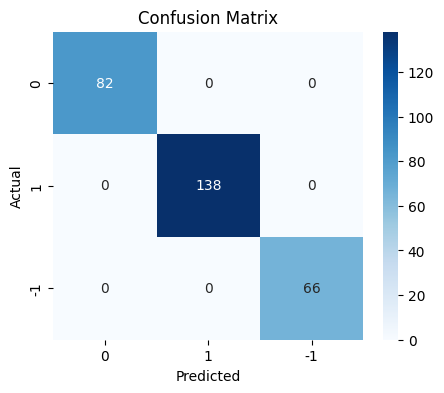

In [ ]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

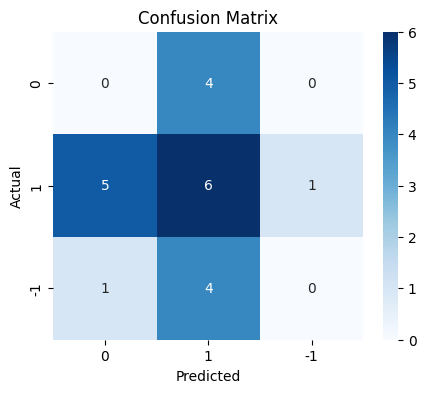

In [ ]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.285714  0.285714   0.244898  0.263736


# **Base Model - GloVe**

In [ ]:
#Building the model
base_gl = RandomForestClassifier(random_state = 42)


# Fitting on train data
base_gl.fit(X_train_gl, y_train)

RandomForestClassifier(random_state=42)

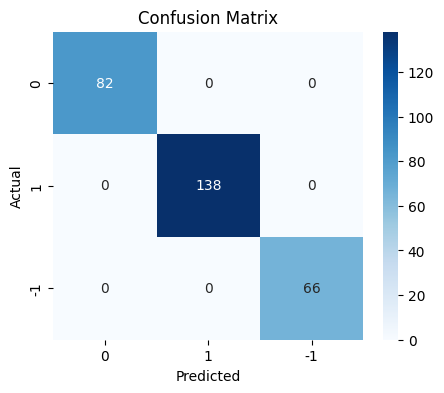

In [ ]:
plot_confusion_matrix(base_gl, X_train_gl, y_train)

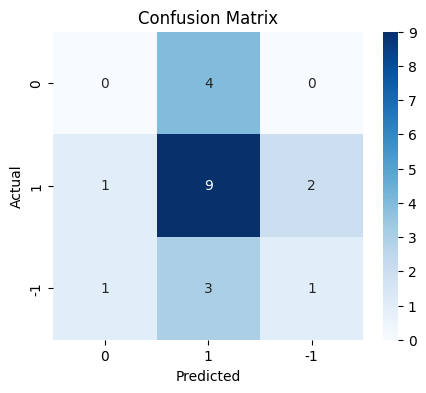

In [ ]:
plot_confusion_matrix(base_gl, X_val_gl, y_val)

In [ ]:
#Calculating different metrics on training data
base_train_gl=model_performance_classification_sklearn(base_gl,X_train_gl,y_train)
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_gl = model_performance_classification_sklearn(base_gl,X_val_gl,y_val)
print("Validation performance:\n",base_val_gl)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.400794  0.426871


# **Base Model - Sentence Transformer**

In [ ]:
# Building the model
base_st = DecisionTreeClassifier(random_state = 42)

# Fitting on train data
base_st.fit(X_train_st, y_train)

DecisionTreeClassifier(random_state=42)

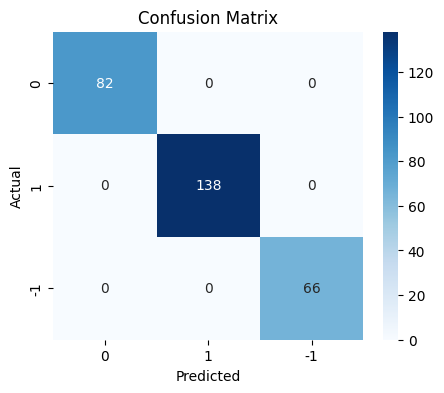

In [ ]:
plot_confusion_matrix(base_st,X_train_st,y_train)

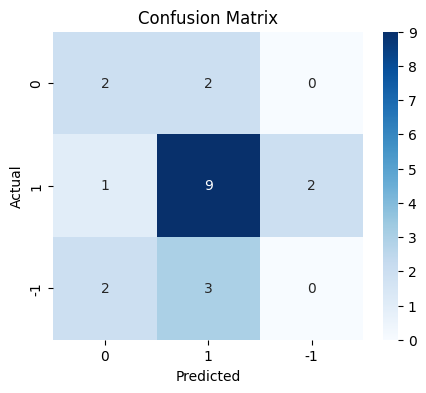

In [ ]:
plot_confusion_matrix(base_st,X_val_st,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_st=model_performance_classification_sklearn(base_st,X_train_st,y_train)
print("Training performance:\n", base_train_st)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_st = model_performance_classification_sklearn(base_st,X_val_st,y_val)
print("Validation performance:\n",base_val_st)

Validation performance:
    Accuracy   Recall  Precision       F1
0   0.52381  0.52381   0.443537  0.48026


# **Tuned Model - Word2Vec**

In [ ]:
# Building the model
start = time.time()
tuned_wv = RandomForestClassifier(random_state = 42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

Time taken  193.86903882026672


In [ ]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

RandomForestClassifier(max_depth=np.int64(5), max_features=0.4,
                       min_samples_split=np.int64(9), random_state=42)

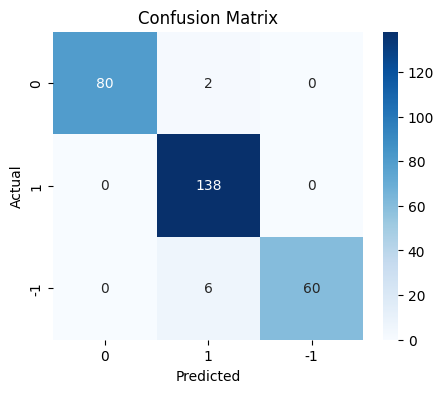

In [ ]:
plot_confusion_matrix(tuned_wv,X_train_wv,y_train)

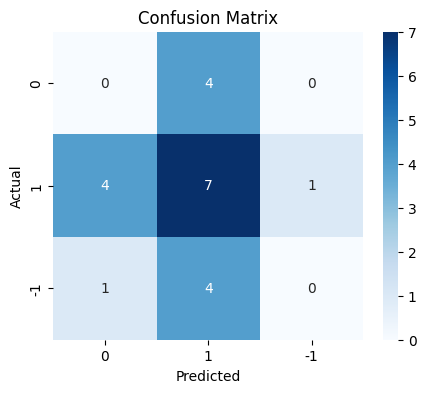

In [ ]:
plot_confusion_matrix(tuned_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv = model_performance_classification_sklearn(tuned_wv,X_train_wv,y_train)
print("Training performance:\n", tuned_train_wv)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.972028  0.972028   0.973561  0.971879


In [ ]:
#Calculating different metrics on validation data
tuned_val_wv = model_performance_classification_sklearn(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.333333  0.333333   0.266667  0.296296


**Tuned Model - GloVe**

In [ ]:
# Building the model
start = time.time()
tuned_gl = RandomForestClassifier(random_state = 42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_gl, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

Time taken  108.65170478820801


In [ ]:
# Fit the best algorithm to the data.
tuned_gl.fit(X_train_gl, y_train)

RandomForestClassifier(max_depth=np.int64(6), max_features=0.2,
                       min_samples_split=np.int64(7), random_state=42)

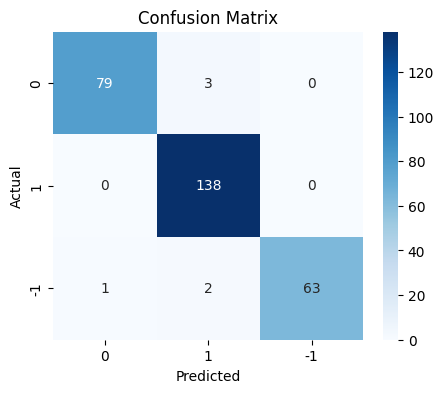

In [ ]:
plot_confusion_matrix(tuned_gl,X_train_gl,y_train)

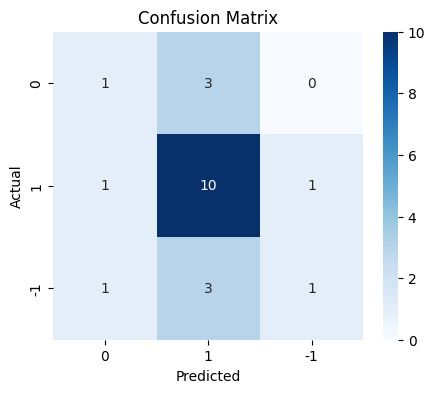

In [ ]:
plot_confusion_matrix(tuned_gl,X_val_gl,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_gl = model_performance_classification_sklearn(tuned_gl,X_train_gl,y_train)
print("Training performance:\n", tuned_train_gl)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.979021  0.979021   0.979545  0.978968


In [ ]:
#Calculating different metrics on validation data
tuned_val_gl = model_performance_classification_sklearn(tuned_gl,X_val_gl,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.333333  0.333333   0.266667  0.296296


**Tuned Model - Sentence Transformer**

In [ ]:
# Building the model
start = time.time()
tuned_st = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_st, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

Time taken  6.381511211395264


In [ ]:
# Fit the best algorithm to the data.
tuned_st.fit(X_train_st, y_train)

DecisionTreeClassifier(max_depth=np.int64(6), max_features='log2',
                       min_samples_split=np.int64(7), random_state=42)

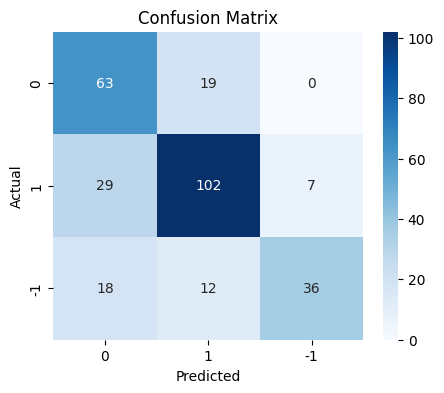

In [ ]:
plot_confusion_matrix(tuned_st,X_train_st,y_train)

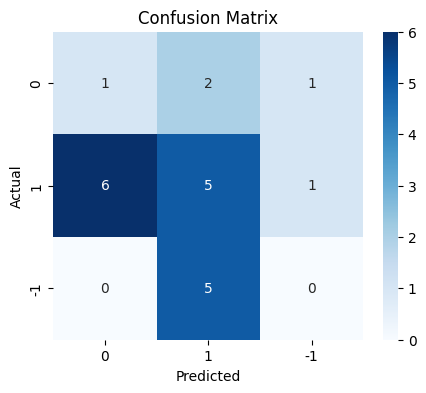

In [ ]:
plot_confusion_matrix(tuned_st,X_val_st,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_st = model_performance_classification_sklearn(tuned_st,X_train_st,y_train)
print("Training performance:\n", tuned_train_st)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.702797  0.702797   0.727462  0.703814


In [ ]:
#Calculating different metrics on validation data
tuned_val_st = model_performance_classification_sklearn(tuned_st,X_val_st,y_val)
print("Validation performance:\n",tuned_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.285714  0.285714   0.265306  0.272727


**Model Performances & Model Selection**

In [ ]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_gl.T,
     base_train_st.T,
     tuned_train_wv.T,
     tuned_train_gl.T,
     tuned_train_st.T,
    ],axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,1.0,1.0,1.0,0.972028,0.979021,0.702797
Recall,1.0,1.0,1.0,0.972028,0.979021,0.702797
Precision,1.0,1.0,1.0,0.973561,0.979545,0.727462
F1,1.0,1.0,1.0,0.971879,0.978968,0.703814


In [ ]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_wv.T,
     tuned_val_gl.T,
     tuned_val_st.T,
     ],axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,0.285714,0.476190,0.523810,0.333333,0.571429,0.285714
Recall,0.285714,0.476190,0.523810,0.333333,0.571429,0.285714
Precision,0.244898,0.400794,0.443537,0.266667,0.539683,0.265306
F1,0.263736,0.426871,0.480260,0.296296,0.530612,0.272727


Observation

The Tuned Model (GloVe) has the highest accuracy (0.571429), recall (0.571429), and F1 score (0.530612), indicating a well-balanced performance with good precision (0.539683).
It shows significant improvement over base models and is suitable for applications requiring high recall and balanced precision, even with a moderate number of false positives.

# **Check Selected Model on Test Data**

Tuned Model (GloVe)

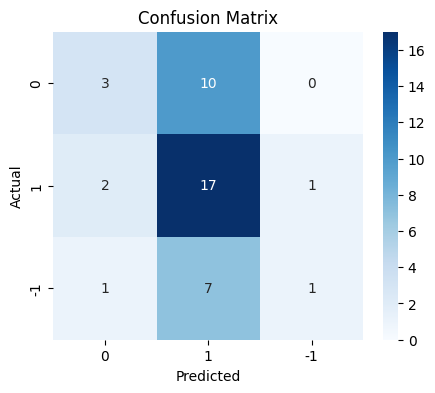

In [ ]:
plot_confusion_matrix(tuned_gl,X_test_gl,y_test)

In [ ]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(tuned_gl,X_test_gl,y_test) #Complete the code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy  Recall  Precision        F1
0       0.5     0.5        0.5  0.436529


Observation

The final model shows balanced accuracy, recall, and precision at 0.5 each, but the F1 score is slightly lower at 0.436529.
While the model is consistent in identifying relevant instances and minimizing false positives, the lower F1 score suggests there might be room for improvement in balancing precision and recall.

**Weekly News Summarization**
Important Note: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

Installing and Importing the necessary libraries

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 190.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 153.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.1 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
opencv-python-headle

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

##from tqdm import tqdm # For progress bar related functionalities
#tqdm.pandas()
#cc
from tqdm.auto import tqdm


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
  data = pd.read_csv('/content/drive/MyDrive/stock_news.csv')

# **Loading the model**

In [ ]:
# Load Mistral model
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [ ]:
model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
)

In [ ]:
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 0 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


**Aggregating the data weekly**

In [ ]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [ ]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

Summarization

Note:


The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

Role: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

Example: You are an expert data analyst specializing in news content analysis.
Task: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

Example: Analyze the provided news headline and return the main topics contained within it.

Instructions: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

Example:
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
Output Format: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

Example: Return the output in JSON format with keys as the topic number and values as the actual topic.
Full Prompt Example:

You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
Sample Output:

{"1": "Politics", "2": "Economy", "3": "Health" }

Utility Functions

In [ ]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

In [ ]:
# Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=512,
      temperature=0,
      top_p=0.95,
      top_k=50,
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

Checking the model output on a sample

Note: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [ ]:
news = data_1.loc[8, 'News']

In [ ]:
print(len(news.split(' ')))
news

422


" The Dow Jones Industrial Average and other major indexes posted gains on Monday, with the Dow rising 60 points, after President Trump announced progress in trade talks with China and delayed tariff hikes. Trade-sensitive stocks like Boeing and Caterpillar performed well, but some tariffs are expected to remain as an enforcement mechanism ||  AAC Technologies Holdings, an Apple supplier based in Hong Kong, reported a significant decrease in expected net profit for Q1 2019 due to reduced orders from customers. The company forecasted a profit decline of 65-75% compared to the same period last year and narrowing gross profit margins. AAC ||  Huawei, the world's third-largest smartphone vendor, showcased its new folding phone, the Mate X, on February 24. The device is designed for next-generation 5G networks and promises super-fast internet speeds. Despite US efforts to exclude the Chinese company from 5G networks ||  Sony, aiming to differentiate itself in the smartphone market, unveiled

In [ ]:
# prompt for this task
prompt = """
    You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
"""

In [ ]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)

 [
        1: "Trade Talks between US and China",
        2: "President Trump's Announcement on Tariff Hikes and Trade-sensitive Stocks",
        3: "AAC Technologies Holdings' Decrease in Net Profit and Reduced Orders",
        4: "Huawei's New Folding Phone, Mate X, and US Exclusion from 5G Networks",
        5: "Sony's New Flagship Xperia 1 with HDR OLED Screen and Professional-grade Camera Capabilities",
        6: "Warren Buffett's Unexpected Exit from Oracle Corp",
        7: "Huawei's Defense of Position as Global Tech Leader amid Trade Tensions",
        8: "AAC Technologies Holdings Inc's Significant Decrease in First-quarter Profits",
        9: "Apple's Layoffs from Project Titan",
        10: "Spotify's Entry into Indian Market"
      ]
CPU times: user 13min 20s, sys: 1.45 s, total: 13min 22s
Wall time: 13min 59s


Checking the model output on the weekly data

In [ ]:
#cc
%%time
data_1.loc[:0, 'Key Events'] = data_1.loc[:0, 'News'].progress_apply(
    lambda x: response_mistral_1(prompt, x)
)


100%|██████████| 1/1 [58:24<00:00, 3504.70s/it]

CPU times: user 55min 49s, sys: 8.65 s, total: 55min 57s
Wall time: 58min 24s


In [ ]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

100%|██████████| 18/18 [7:02:51<00:00, 1409.54s/it]

CPU times: user 6h 43min 37s, sys: 1min 3s, total: 6h 44min 41s
Wall time: 7h 2min 51s


In [ ]:
data_1['Key Events'].notna().sum()


np.int64(18)

In [ ]:
data_1['Key Events'].head()

,Key Events
0,"[\n {\n ""topic_1"": ""Apple's Q..."
1,"1. 5G smartphones: Sprint, Samsung, nine U.S. ..."
2,"{\n ""1"": ""U.S. stock market decline"",..."
3,"{\n ""1"": ""Swiss National Bank (SNB) a..."
4,"{\n ""1"": ""Caterpillar Inc's lower-th..."


**Formatting the model output**

In [ ]:
##CC
import json
import re
import pandas as pd

def extract_json_data(text):
    # Handle NaN / None / non-string
    if not isinstance(text, str):
        return None

    # Try to extract JSON block using regex
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if not match:
        return None

    json_str = match.group()

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        return None


In [ ]:
#cc

import json
import re

def extract_json_data(text):
    if not isinstance(text, str):
        return None

    # Try to extract JSON (list or object)
    match = re.search(r'(\{.*\}|\[.*\])', text, re.DOTALL)
    if not match:
        return None

    json_str = match.group()

    try:
        parsed = json.loads(json_str)

        # If list, take first element
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0]

        # If dict, return directly
        if isinstance(parsed, dict):
            return parsed

        return None

    except json.JSONDecodeError:
        return None


In [ ]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,"[\n {\n ""topic_1"": ""Apple's Q...",{'topic_1': 'Apple's Q1 revenue warning and it...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"1. 5G smartphones: Sprint, Samsung, nine U.S. ...",None
2,2019-01-20,The U.S. stock market declined on Monday as c...,"{\n ""1"": ""U.S. stock market decline"",...","{'1': 'U.S. stock market decline', '2': 'Globa..."
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","{\n ""1"": ""Swiss National Bank (SNB) a...",{'1': 'Swiss National Bank (SNB) and negative ...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"{\n ""1"": ""Caterpillar Inc's lower-th...",None


In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

,topic_1,keywords,1,2,3,4,5,6,7,8,...,20,21,22,23,24,25,26,27,28,29
0,Apple's Q1 revenue warning and its impact on t...,"[Apple, Q1 revenue warning, tech stocks, notab...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,U.S. stock market decline,Global economic slowdown concerns,Chinese exports and imports drop,Tech stocks losses,Philadelphia SE Semiconductor Index fall,European stock market rally halt,Luxury goods sectors selling,Chinese auto market contraction in 2018,...,Netflix price increase for U.S. subscribers,Belarus regulated tokenized securities exchang...,Apple hiring cuts following lower-than-expecte...,Chinese Academy of Social Sciences criticizes ...,Belarus platform enabling investors to buy rea...,Apple banned from using part of a press releas...,U.S. and Chinese officials discuss possibility...,NaN,NaN,NaN
3,NaN,NaN,Swiss National Bank (SNB) and negative interes...,"Stock market losses for Dow, S&P 500, Nasdaq a...",IBM's better-than-expected earnings and revenu...,Huawei's new Honor View20 smartphone launch in...,Foxconn recruitment drive and potential mass l...,Amazon's direct fulfillment and delivery netwo...,Tesla's potential battery supplier negotiation...,TomTom fleet management business sale to Bridg...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
# Get the existing column count
num_columns = len(final_output.columns)
# Create a list of new column names with the correct length
new_column_names = ['Week End Date', 'News'] + [f'Column_{i}' for i in range(2, num_columns)]
# Assign the new column names
final_output.columns = new_column_names

final_output.head()

,Week End Date,News,Column_2,Column_3,Column_4,Column_5,Column_6,Column_7,Column_8,Column_9,...,Column_23,Column_24,Column_25,Column_26,Column_27,Column_28,Column_29,Column_30,Column_31,Column_32
0,2019-01-06,The tech sector experienced a significant dec...,Apple's Q1 revenue warning and its impact on t...,"[Apple, Q1 revenue warning, tech stocks, notab...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-20,The U.S. stock market declined on Monday as c...,NaN,NaN,U.S. stock market decline,Global economic slowdown concerns,Chinese exports and imports drop,Tech stocks losses,Philadelphia SE Semiconductor Index fall,European stock market rally halt,...,Netflix price increase for U.S. subscribers,Belarus regulated tokenized securities exchang...,Apple hiring cuts following lower-than-expecte...,Chinese Academy of Social Sciences criticizes ...,Belarus platform enabling investors to buy rea...,Apple banned from using part of a press releas...,U.S. and Chinese officials discuss possibility...,NaN,NaN,NaN
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",NaN,NaN,Swiss National Bank (SNB) and negative interes...,"Stock market losses for Dow, S&P 500, Nasdaq a...",IBM's better-than-expected earnings and revenu...,Huawei's new Honor View20 smartphone launch in...,Foxconn recruitment drive and potential mass l...,Amazon's direct fulfillment and delivery netwo...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Conclusions and Recommendations
From the exploratory data analysis (EDA) conducted on the dataset, we observed a positive correlation between news sentiments and stock prices. Positive sentiments often lead to an increase in stock prices, and vice versa.
We developed models using Word2Vec, GloVe, and Sentence Transformers to classify news into various sentiment categories.
Among the base and tuned models, the GloVe model with a Random Forest classifier performed the best on validation and testing data, achieving accuracy, recall, and precision scores of 0.5 each. However, the F1 score was slightly lower at 0.436529.
Additionally, we implemented an automated process to analyze stock-related news headlines using a Large Language Model (LLM) from the Mistral-7B model, categorizing them into key positive and negative events likely to impact stock prices.
We can enhance our responses by making our prompts more specific and fine-tuning certain parameters in our model.